In [1]:
import os
import re
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
CFG = {
    "data_root": r"C:\\Users\\ASHAH\\Desktop\\DL_Project\\breast_ultrasound\\combined_breast_ultrasound_dataset",
    "img_size": 320,
    "batch_size": 8,
    "epochs": 60,
    "lr": 3e-4,
    "num_workers": 0,
    "encoder_name": "timm-efficientnet-b3",
    "threshold": 0.5,
    "num_classes": 3,          # benign, malignant, normal
    "cls_weight": 0.8,         # keep classification active in the joint loss
    "unfreeze_epoch": 5,       # sample-style segmentation schedule
    "patience": 12,
    # Keep normalization for the pretrained encoder
    "norm_mean": 0.485,
    "norm_std":  0.229,
}

LABEL2IDX = {"benign": 0, "malignant": 1, "normal": 2}
IDX2LABEL  = {v: k for k, v in LABEL2IDX.items()}


In [3]:
DATASET_ROOT = Path(CFG["data_root"])

def base_key(filename: str) -> str:
    name = filename.replace(".png", "")
    name = re.sub(r"_mask(_\\d+)?$", "", name)
    return name

rows = []
for cls_name in ["benign", "malignant", "normal"]:
    cls_dir  = DATASET_ROOT / cls_name
    img_dir  = cls_dir / "images"
    mask_dir = cls_dir / "masks"

    masks = {
        re.sub(r"_mask$", "", p.stem): str(p)
        for p in mask_dir.glob("*.png")
    }

    for img_path in sorted(img_dir.glob("*.png")):
        key = img_path.stem
        rows.append({
            "image_path": str(img_path),
            "mask_path":  masks.get(key, None),
            "label":      cls_name,
            "label_idx":  LABEL2IDX[cls_name],
        })

df = pd.DataFrame(rows)
print(df["label"].value_counts())
print("Total:", len(df))
print("With mask:", df["mask_path"].notna().sum())
print("Without mask:", df["mask_path"].isna().sum())


label
normal       729
benign       477
malignant    261
Name: count, dtype: int64
Total: 1467
With mask: 1467
Without mask: 0


In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print(train_df["label"].value_counts(), "\n")
print("Valid:", len(valid_df))
print(valid_df["label"].value_counts(), "\n")
print("Test:", len(test_df))
print(test_df["label"].value_counts())

# ── Compute class weights for imbalanced CrossEntropy ────────────────────────
from collections import Counter
counts   = Counter(train_df["label_idx"].tolist())
n_total  = len(train_df)
cls_wts  = torch.tensor(
    [n_total / (CFG["num_classes"] * counts[i]) for i in range(CFG["num_classes"])],
    dtype=torch.float32
).to(device)
print("\nClass weights:", cls_wts)


Train: 1026
label
normal       510
benign       334
malignant    182
Name: count, dtype: int64 

Valid: 220
label
normal       109
benign        71
malignant     40
Name: count, dtype: int64 

Test: 221
label
normal       110
benign        72
malignant     39
Name: count, dtype: int64

Class weights: tensor([1.0240, 1.8791, 0.6706], device='cuda:0')


In [6]:
train_tfms_noaug = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])

valid_tfms_noaug = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])


train_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Affine(                        
        translate_percent=0.05,
        scale=(0.90, 1.10),
        rotate=(-15, 15),
        fill=0,                      
        p=0.5
    ),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.GaussNoise(p=0.2),
])

valid_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])


In [7]:
class BUSISegDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms
        self.mean       = CFG["norm_mean"]
        self.std        = CFG["norm_std"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(row["image_path"])

        # ── Mask ─────────────────────────────────────────────────────────────
        mask_path = row["mask_path"]
        if mask_path and Path(mask_path).exists():
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros(image.shape, dtype=np.float32)  # normal class

        h, w = CFG["img_size"], CFG["img_size"]
        image = cv2.resize(image, (w, h), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  (w, h), interpolation=cv2.INTER_NEAREST)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask  = transformed["mask"]

        # ── Normalise with ImageNet stats (single channel) ───────────────────
        image = image.astype(np.float32) / 255.0
        image = (image - self.mean) / self.std          # ← FIX: was missing

        image = np.expand_dims(image, axis=0)
        mask  = np.expand_dims(mask.astype(np.float32), axis=0)

        return {
            "image":      torch.tensor(image, dtype=torch.float32),
            "mask":       torch.tensor(mask,  dtype=torch.float32),
            "label":      row["label"],
            "label_idx":  torch.tensor(row["label_idx"], dtype=torch.long),
            "has_lesion": torch.tensor(float(mask.max() > 0), dtype=torch.float32),
        }


In [8]:
class DualTaskModel(nn.Module):
    """
    Dual-task model:
      - segmentation branch follows the sample notebook's DeepLabV3+ pipeline
      - classification branch pools encoder features from the same backbone
    """
    def __init__(self, encoder_name, num_classes=3):
        super().__init__()
        self.seg_model = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights="imagenet",
            in_channels=1,
            classes=1,
            activation=None,
        )

        dummy = torch.zeros(1, 1, CFG["img_size"], CFG["img_size"])
        with torch.no_grad():
            enc_out = self.seg_model.encoder(dummy)

        c_last = enc_out[-1].shape[1]
        c_prev = enc_out[-2].shape[1]

        self.cls_pool_a = nn.AdaptiveAvgPool2d(1)
        self.cls_pool_b = nn.AdaptiveAvgPool2d(1)

        fused_dim = c_last + c_prev
        self.cls_head = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # segmentation path kept explicit so classification can reuse encoder features
        enc_features = self.seg_model.encoder(x)
        decoder_out  = self.seg_model.decoder(enc_features)
        seg_logits   = self.seg_model.segmentation_head(decoder_out)

        feat_a = self.cls_pool_a(enc_features[-1]).flatten(1)
        feat_b = self.cls_pool_b(enc_features[-2]).flatten(1)
        cls_logits = self.cls_head(torch.cat([feat_a, feat_b], dim=1))
        return seg_logits, cls_logits

    def freeze_encoder(self):
        for p in self.seg_model.encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoder(self):
        for p in self.seg_model.encoder.parameters():
            p.requires_grad = True


_tmp = DualTaskModel(CFG["encoder_name"], CFG["num_classes"]).to(device)
_x   = torch.randn(2, 1, CFG["img_size"], CFG["img_size"]).to(device)
with torch.no_grad():
    _seg, _cls = _tmp(_x)
print("Seg logits shape:", _seg.shape)
print("Cls logits shape:", _cls.shape)
del _tmp, _x, _seg, _cls


Seg logits shape: torch.Size([2, 1, 320, 320])
Cls logits shape: torch.Size([2, 3])


In [9]:
dice_loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss_fn  = nn.BCEWithLogitsLoss()
ce_loss_fn   = nn.CrossEntropyLoss(weight=cls_wts)

def compute_combined_loss(seg_logits, cls_logits, masks, labels, has_lesion):
    """
    Keep the dual-task objective, but make the segmentation loss follow the sample:
      - segmentation loss is Dice + BCE on the full batch
      - classification loss remains weighted CrossEntropy
    """
    seg_loss = dice_loss_fn(seg_logits, masks) + bce_loss_fn(seg_logits, masks)
    cls_loss = ce_loss_fn(cls_logits, labels)
    total = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


In [27]:
def dice_score_from_logits(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    dice  = (2 * inter + eps) / (union + eps)
    return dice.mean().item()

def cls_accuracy(cls_logits, labels):
    preds = cls_logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


In [11]:
def make_loaders(train_tfms, val_tfms, tag="aug"):
    train_ds = BUSISegDataset(train_df, transforms=train_tfms)
    valid_ds = BUSISegDataset(valid_df, transforms=val_tfms)
    test_ds  = BUSISegDataset(test_df,  transforms=val_tfms)

    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True,  num_workers=CFG["num_workers"], pin_memory=True)
    valid_loader = DataLoader(valid_ds, batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=0, pin_memory=True)
    print(f"[{tag}] train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")
    return train_loader, valid_loader, test_loader, valid_ds, test_ds


In [12]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    totals = dict(loss=0, seg_loss=0, cls_loss=0, dice=0, acc=0)

    pbar = tqdm(loader, total=len(loader))
    for batch in pbar:
        images     = batch["image"].to(device, non_blocking=True)
        masks      = batch["mask"].to(device, non_blocking=True)
        labels     = batch["label_idx"].to(device, non_blocking=True)
        has_lesion = batch["has_lesion"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            seg_logits, cls_logits = model(images)
            loss, seg_l, cls_l = compute_combined_loss(
                seg_logits, cls_logits, masks, labels, has_lesion
            )

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score_from_logits(seg_logits.detach(), masks)
        totals["acc"]      += cls_accuracy(cls_logits.detach(), labels)

        n = pbar.n + 1
        pbar.set_postfix({k: f"{v/n:.4f}" for k, v in totals.items()})

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


@torch.no_grad()
def valid_one_epoch(model, loader):
    model.eval()
    totals = dict(loss=0, seg_loss=0, cls_loss=0, dice=0, acc=0)

    for batch in tqdm(loader, total=len(loader)):
        images     = batch["image"].to(device, non_blocking=True)
        masks      = batch["mask"].to(device, non_blocking=True)
        labels     = batch["label_idx"].to(device, non_blocking=True)
        has_lesion = batch["has_lesion"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            seg_logits, cls_logits = model(images)
            loss, seg_l, cls_l = compute_combined_loss(
                seg_logits, cls_logits, masks, labels, has_lesion
            )

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score_from_logits(seg_logits, masks)
        totals["acc"]      += cls_accuracy(cls_logits, labels)

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


In [13]:
def run_experiment(tag, train_tfms, val_tfms, save_path):
    print("\n" + "="*60)
    print(f"  EXPERIMENT: {tag}")
    print("="*60)

    train_loader, valid_loader, test_loader, valid_ds, test_ds = \
        make_loaders(train_tfms, val_tfms, tag)

    model = DualTaskModel(CFG["encoder_name"], CFG["num_classes"]).to(device)
    model.freeze_encoder()
    print("Encoder frozen ✓")

    # Separate LR for encoder vs. head (lower LR when encoder unfreezes)
    head_params    = list(model.cls_head.parameters()) + \
                     list(model.cls_pool_a.parameters()) + \
                     list(model.cls_pool_b.parameters()) + \
                     list(model.seg_model.decoder.parameters()) + \
                     list(model.seg_model.segmentation_head.parameters())
    encoder_params = list(model.seg_model.encoder.parameters())

    optimizer = torch.optim.AdamW([
        {"params": head_params,    "lr": CFG["lr"]},
        {"params": encoder_params, "lr": CFG["lr"] * 0.1},  # 10x lower for encoder
    ], weight_decay=1e-2)

    scaler    = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=1e-6
    )

    history    = {k: [] for k in ["train_loss","train_dice","train_acc",
                                    "val_loss","val_dice","val_acc"]}
    best_score = -1
    patience   = CFG["patience"]
    no_improve = 0

    for epoch in range(CFG["epochs"]):
        if epoch == CFG["unfreeze_epoch"]:
            model.unfreeze_encoder()
            print(f"Encoder unfrozen at epoch {epoch+1} ✓")

        tr = train_one_epoch(model, train_loader, optimizer, scaler)
        vl = valid_one_epoch(model, valid_loader)
        scheduler.step()

        history["train_loss"].append(tr["loss"])
        history["train_dice"].append(tr["dice"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(vl["loss"])
        history["val_dice"].append(vl["dice"])
        history["val_acc"].append(vl["acc"])

        # Combined score: 60% Dice + 40% Acc
        combined = 0.6 * vl["dice"] + 0.4 * vl["acc"]

        print(f"\nEpoch {epoch+1}/{CFG['epochs']}  [{tag}]")
        print(f"  Train  loss={tr['loss']:.4f}  dice={tr['dice']:.4f}  acc={tr['acc']:.4f}")
        print(f"  Val    loss={vl['loss']:.4f}  dice={vl['dice']:.4f}  acc={vl['acc']:.4f}")
        print(f"  Combined score={combined:.4f}  LR: {scheduler.get_last_lr()[0]:.2e}")

        if combined > best_score:
            best_score = combined
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best model (score={combined:.4f}) → {save_path}")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    return history, model, train_loader, valid_loader, test_loader, valid_ds, test_ds


## Experiment 1 — Without Augmentation (Baseline)

In [14]:
history_noaug, model_noaug, \
    train_loader_noaug, valid_loader_noaug, test_loader_noaug, \
    valid_ds_noaug, test_ds_noaug = run_experiment(
        tag         = "NoAug",
        train_tfms  = train_tfms_noaug,
        val_tfms    = valid_tfms_noaug,
        save_path   = "best_noaug_model_sample_seg.pth",
)



  EXPERIMENT: NoAug
[NoAug] train=1026  valid=220  test=221
Encoder frozen ✓


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 1/60  [NoAug]
  Train  loss=1.9808  dice=0.2284  acc=0.5959
  Val    loss=1.5657  dice=0.4215  acc=0.6696
  Combined score=0.5208  LR: 2.98e-04
  ✓ Saved best model (score=0.5208) → best_noaug_model_sample_seg.pth


  0%|          | 0/129 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 59/60  [NoAug]
  Train  loss=0.1852  dice=0.9451  acc=0.9545
  Val    loss=1.8031  dice=0.7956  acc=0.7634
  Combined score=0.7827  LR: 2.84e-06


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 60/60  [NoAug]
  Train  loss=0.1775  dice=0.9493  acc=0.9535
  Val    loss=1.4635  dice=0.7674  acc=0.7545
  Combined score=0.7622  LR: 3.00e-04


In [36]:
best_epoch_idx = history_noaug["val_dice"].index(max(history_noaug["val_dice"]))
print("=" * 55)
print("  BEST MODEL — No-Aug")
print("=" * 55)
print(f"  Best Epoch   : {best_epoch_idx + 1}")
print(f"  {'Metric':<15} {'Train':>10} {'Val':>10}")
print(f"  {'-'*37}")
print(f"  {'Loss':<15} {history_noaug['train_loss'][best_epoch_idx]:>10.4f} {history_noaug['val_loss'][best_epoch_idx]:>10.4f}")
print(f"  {'Dice':<15} {history_noaug['train_dice'][best_epoch_idx]:>10.4f} {history_noaug['val_dice'][best_epoch_idx]:>10.4f}")
print(f"  {'Accuracy':<15} {history_noaug['train_acc'][best_epoch_idx]:>10.4f} {history_noaug['val_acc'][best_epoch_idx]:>10.4f}")
print("=" * 55)

  BEST MODEL — No-Aug
  Best Epoch   : 58
  Metric               Train        Val
  -------------------------------------
  Loss                0.1583     1.7469
  Dice                0.9402     0.8072
  Accuracy            0.9583     0.7545


In [33]:
best_epoch_idx = history_noaug["val_dice"].index(max(history_noaug["val_dice"]))
print("=" * 55)
print("  BEST MODEL — No-Aug")
print("=" * 55)
print(f"  Best Epoch   : {best_epoch_idx + 1}")
print(f"  {'Metric':<15} {'Train':>10} {'Val':>10}")
print(f"  {'-'*37}")
print(f"  {'Loss':<15} {history_noaug['train_loss'][best_epoch_idx]:>10.4f} {history_noaug['val_loss'][best_epoch_idx]:>10.4f}")
print(f"  {'Dice':<15} {history_noaug['train_dice'][best_epoch_idx]:>10.4f} {history_noaug['val_dice'][best_epoch_idx]:>10.4f}")
print(f"  {'Accuracy':<15} {history_noaug['train_acc'][best_epoch_idx]:>10.4f} {history_noaug['val_acc'][best_epoch_idx]:>10.4f}")
print("=" * 55)

  BEST MODEL — No-Aug
  Best Epoch   : 58
  Metric               Train        Val
  -------------------------------------
  Loss                0.1583     1.7469
  Dice                0.9402     0.8072
  Accuracy            0.9583     0.7545


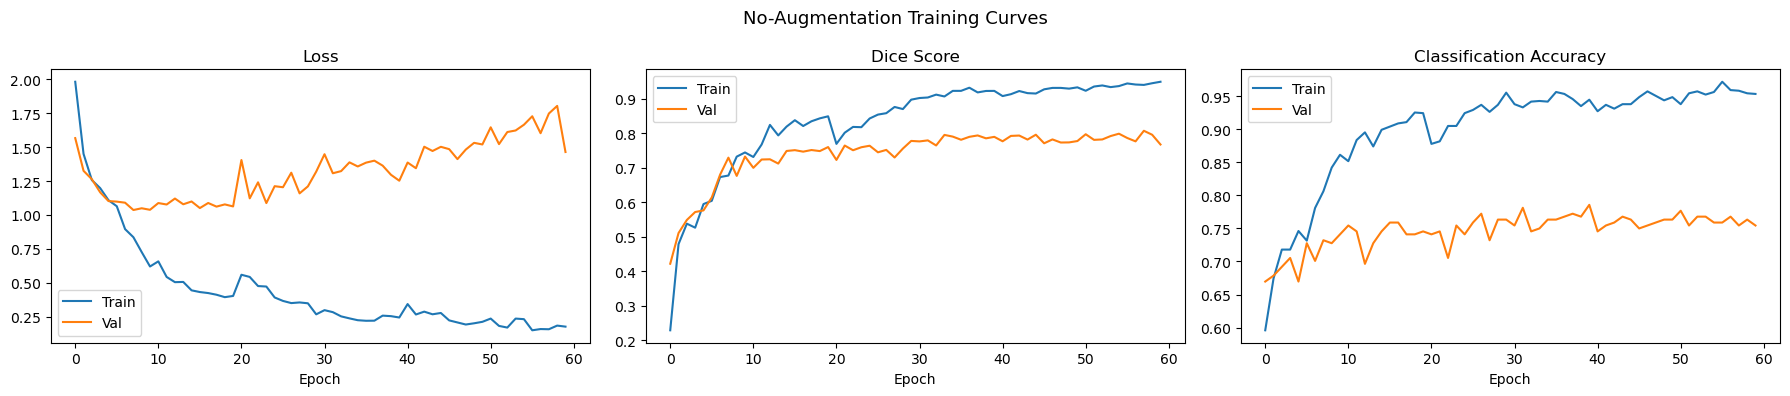

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("No-Augmentation Training Curves", fontsize=13)

axes[0].plot(history_noaug["train_loss"], label="Train")
axes[0].plot(history_noaug["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_noaug["train_dice"], label="Train")
axes[1].plot(history_noaug["val_dice"],   label="Val")
axes[1].set_title("Dice Score"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history_noaug["train_acc"], label="Train")
axes[2].plot(history_noaug["val_acc"],   label="Val")
axes[2].set_title("Classification Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("noaug_training_curves.png", dpi=150)
plt.show()


In [16]:
model_noaug.load_state_dict(torch.load("best_noaug_model_sample_seg.pth", map_location=device))
model_noaug.eval()

test_metrics_noaug = valid_one_epoch(model_noaug, test_loader_noaug)
print("\n[No-Aug] Test Results")
print(f"  Loss={test_metrics_noaug['loss']:.4f}  "
      f"Dice={test_metrics_noaug['dice']:.4f}  "
      f"Cls Acc={test_metrics_noaug['acc']:.4f}")


  0%|          | 0/28 [00:00<?, ?it/s]


[No-Aug] Test Results
  Loss=1.6081  Dice=0.7784  Cls Acc=0.7536



[No-Aug] Classification Report:
              precision    recall  f1-score   support

      benign       0.65      0.75      0.70        72
   malignant       0.79      0.56      0.66        39
      normal       0.83      0.83      0.83       110

    accuracy                           0.76       221
   macro avg       0.75      0.71      0.73       221
weighted avg       0.76      0.76      0.75       221



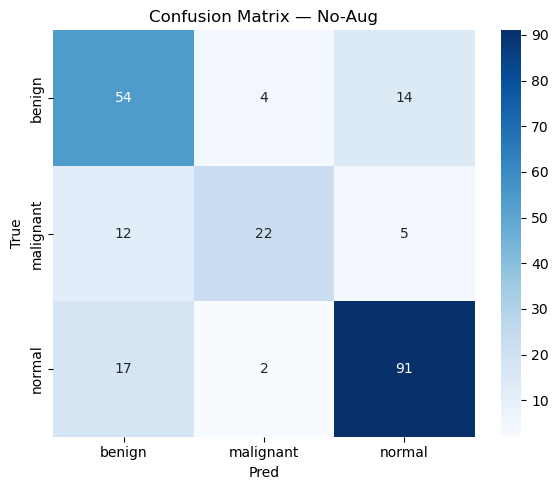

In [17]:
@torch.no_grad()
def collect_cls_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label_idx"]
        _, cls_logits = model(images)
        preds = cls_logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
    return all_labels, all_preds

labels_noaug, preds_noaug = collect_cls_preds(model_noaug, test_loader_noaug)

print("\n[No-Aug] Classification Report:")
print(classification_report(labels_noaug, preds_noaug,
                             target_names=["benign","malignant","normal"]))

cm = confusion_matrix(labels_noaug, preds_noaug)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign","malignant","normal"],
            yticklabels=["benign","malignant","normal"])
plt.title("Confusion Matrix — No-Aug"); plt.ylabel("True"); plt.xlabel("Pred")
plt.tight_layout(); plt.savefig("cm_noaug.png", dpi=150); plt.show()


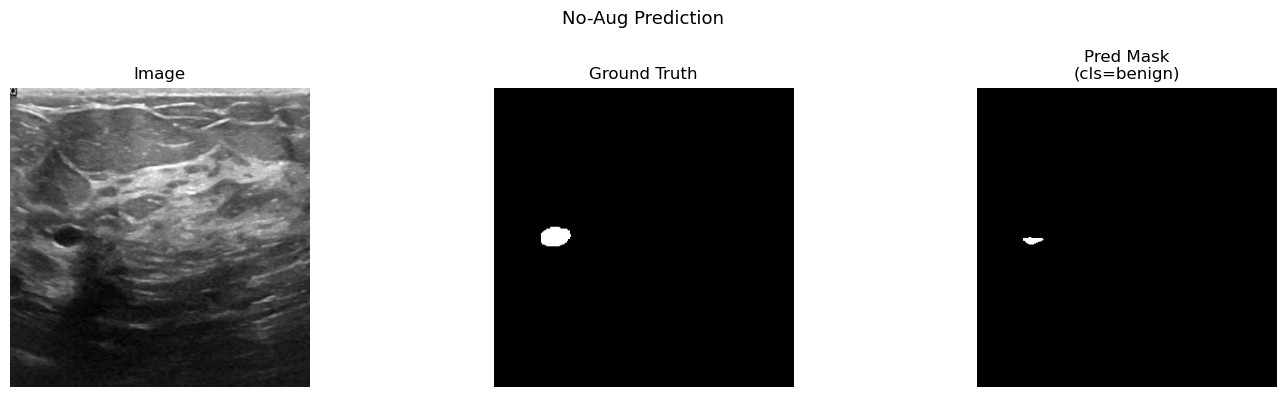

In [18]:
sample = test_ds_noaug[0]
img_t  = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    seg_logits, cls_logits = model_noaug(img_t)
    pred_mask = (torch.sigmoid(seg_logits)[0, 0] > CFG["threshold"]).float().cpu().numpy()
    pred_cls  = IDX2LABEL[cls_logits.argmax(dim=1).item()]

img    = sample["image"][0].numpy()
gt_msk = sample["mask"][0].numpy()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Image"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(gt_msk, cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(pred_mask, cmap="gray")
plt.title(f"Pred Mask\n(cls={pred_cls})"); plt.axis("off")
plt.suptitle("No-Aug Prediction", fontsize=13)
plt.tight_layout(); plt.savefig("noaug_prediction.png", dpi=150); plt.show()


## Experiment 2 — With Augmentation

In [19]:
history_aug, model_aug, \
    train_loader_aug, valid_loader_aug, test_loader_aug, \
    valid_ds_aug, test_ds_aug = run_experiment(
        tag        = "Aug",
        train_tfms = train_tfms,
        val_tfms   = valid_tfms,
        save_path  = "best_aug_model_sample_seg.pth",
)



  EXPERIMENT: Aug
[Aug] train=1026  valid=220  test=221
Encoder frozen ✓


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 1/60  [Aug]
  Train  loss=2.0159  dice=0.2624  acc=0.4118
  Val    loss=1.5930  dice=0.4906  acc=0.5982
  Combined score=0.5337  LR: 2.98e-04
  ✓ Saved best model (score=0.5337) → best_aug_model_sample_seg.pth


  0%|          | 0/129 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 59/60  [Aug]
  Train  loss=0.6862  dice=0.7802  acc=0.8421
  Val    loss=0.6918  dice=0.8088  acc=0.8304
  Combined score=0.8174  LR: 2.84e-06


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 60/60  [Aug]
  Train  loss=0.6705  dice=0.7787  acc=0.8508
  Val    loss=0.7006  dice=0.7963  acc=0.8259
  Combined score=0.8081  LR: 3.00e-04


In [37]:
best_epoch_idx = history_noaug["val_dice"].index(max(history_noaug["val_dice"]))
print("=" * 55)
print("  BEST MODEL — Aug")
print("=" * 55)
print(f"  Best Epoch   : {best_epoch_idx + 1}")
print(f"  {'Metric':<15} {'Train':>10} {'Val':>10}")
print(f"  {'-'*37}")
print(f"  {'Loss':<15} {history_noaug['train_loss'][best_epoch_idx]:>10.4f} {history_noaug['val_loss'][best_epoch_idx]:>10.4f}")
print(f"  {'Dice':<15} {history_noaug['train_dice'][best_epoch_idx]:>10.4f} {history_noaug['val_dice'][best_epoch_idx]:>10.4f}")
print(f"  {'Accuracy':<15} {history_noaug['train_acc'][best_epoch_idx]:>10.4f} {history_noaug['val_acc'][best_epoch_idx]:>10.4f}")
print("=" * 55)

  BEST MODEL — Aug
  Best Epoch   : 58
  Metric               Train        Val
  -------------------------------------
  Loss                0.1583     1.7469
  Dice                0.9402     0.8072
  Accuracy            0.9583     0.7545


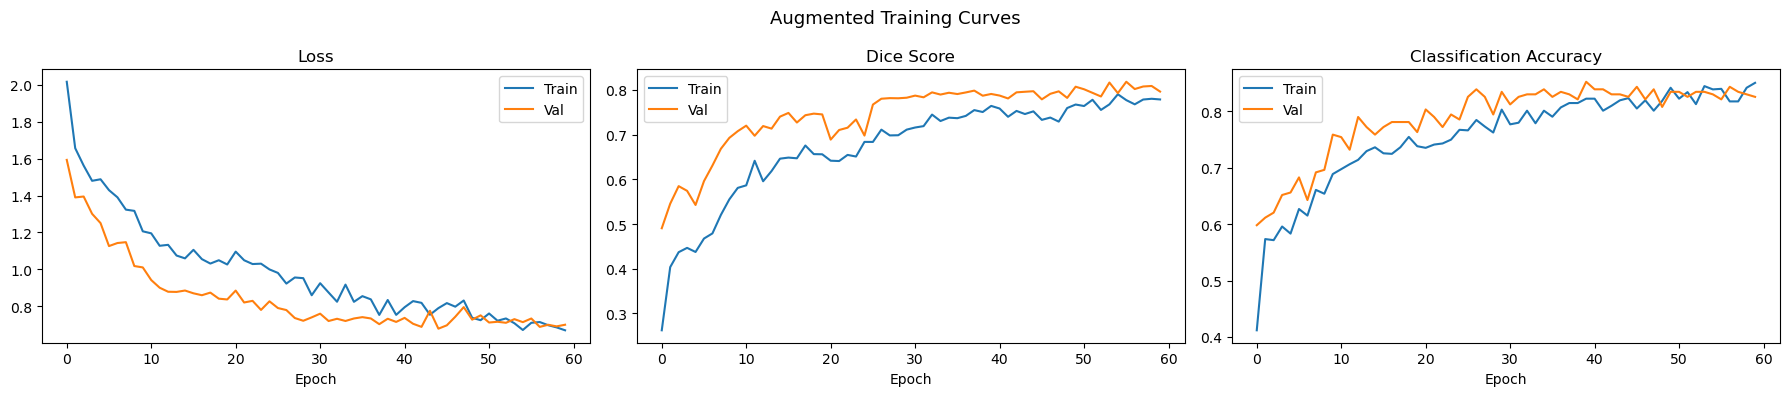

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Augmented Training Curves", fontsize=13)

axes[0].plot(history_aug["train_loss"], label="Train")
axes[0].plot(history_aug["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_aug["train_dice"], label="Train")
axes[1].plot(history_aug["val_dice"],   label="Val")
axes[1].set_title("Dice Score"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history_aug["train_acc"], label="Train")
axes[2].plot(history_aug["val_acc"],   label="Val")
axes[2].set_title("Classification Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("aug_training_curves.png", dpi=150)
plt.show()


In [21]:
model_aug.load_state_dict(torch.load("best_aug_model_sample_seg.pth", map_location=device))
model_aug.eval()

test_metrics_aug = valid_one_epoch(model_aug, test_loader_aug)
print("\n[Aug] Test Results")
print(f"  Loss={test_metrics_aug['loss']:.4f}  "
      f"Dice={test_metrics_aug['dice']:.4f}  "
      f"Cls Acc={test_metrics_aug['acc']:.4f}")


  0%|          | 0/28 [00:00<?, ?it/s]


[Aug] Test Results
  Loss=0.8054  Dice=0.8033  Cls Acc=0.8116



[Aug] Classification Report:
              precision    recall  f1-score   support

      benign       0.79      0.72      0.75        72
   malignant       0.67      0.74      0.71        39
      normal       0.88      0.90      0.89       110

    accuracy                           0.81       221
   macro avg       0.78      0.79      0.78       221
weighted avg       0.82      0.81      0.81       221



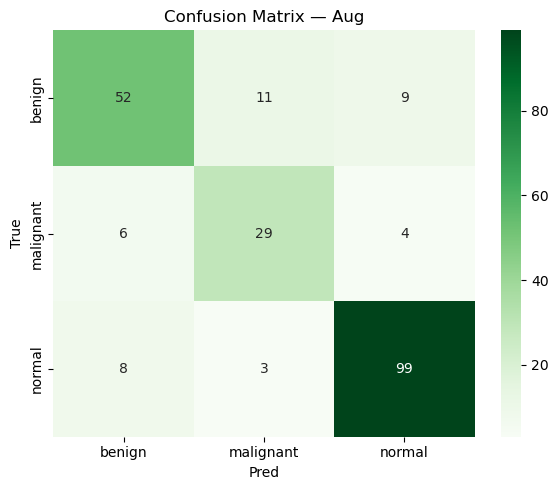

In [22]:
labels_aug, preds_aug = collect_cls_preds(model_aug, test_loader_aug)

print("\n[Aug] Classification Report:")
print(classification_report(labels_aug, preds_aug,
                             target_names=["benign","malignant","normal"]))

cm = confusion_matrix(labels_aug, preds_aug)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["benign","malignant","normal"],
            yticklabels=["benign","malignant","normal"])
plt.title("Confusion Matrix — Aug"); plt.ylabel("True"); plt.xlabel("Pred")
plt.tight_layout(); plt.savefig("cm_aug.png", dpi=150); plt.show()


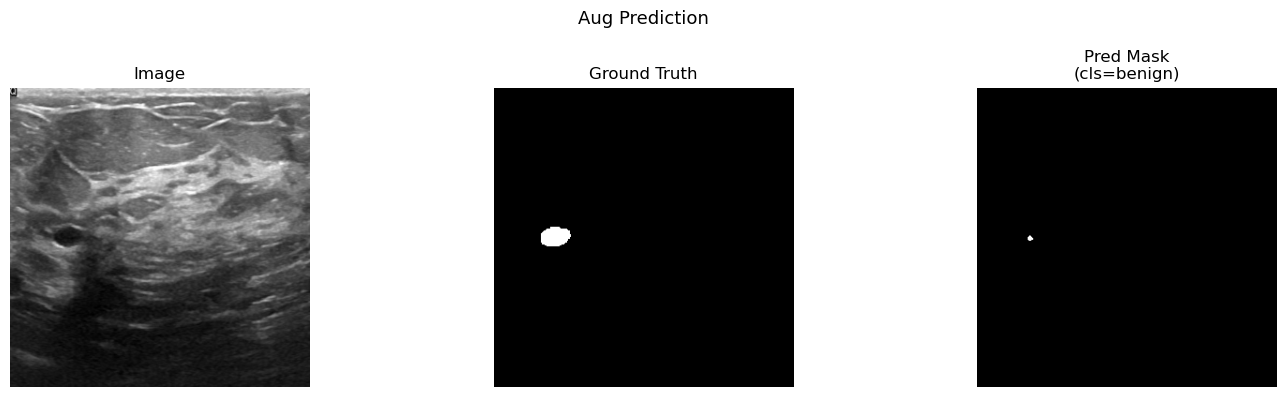

In [23]:
sample = test_ds_aug[0]
img_t  = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    seg_logits, cls_logits = model_aug(img_t)
    pred_mask = (torch.sigmoid(seg_logits)[0, 0] > CFG["threshold"]).float().cpu().numpy()
    pred_cls  = IDX2LABEL[cls_logits.argmax(dim=1).item()]

img    = sample["image"][0].numpy()
gt_msk = sample["mask"][0].numpy()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Image"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(gt_msk, cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(pred_mask, cmap="gray")
plt.title(f"Pred Mask\n(cls={pred_cls})"); plt.axis("off")
plt.suptitle("Aug Prediction", fontsize=13)
plt.tight_layout(); plt.savefig("aug_prediction.png", dpi=150); plt.show()


## Final Comparison: No-Aug vs. Aug

In [24]:
print("=" * 52)
print(f"{'Metric':<22}{'No-Aug':>12}{'Aug':>12}{'Gain':>8}")
print("-" * 52)
for key, label in [("dice","Test Dice"), ("acc","Test Cls Acc"), ("loss","Test Loss")]:
    na   = test_metrics_noaug[key]
    au   = test_metrics_aug[key]
    diff = au - na
    sign = "+" if diff >= 0 else ""
    print(f"  {label:<20}{na:>12.4f}{au:>12.4f}{sign+f'{diff:.4f}':>8}")
print("=" * 52)


Metric                      No-Aug         Aug    Gain
----------------------------------------------------
  Test Dice                 0.7784      0.8033 +0.0249
  Test Cls Acc              0.7536      0.8116 +0.0580
  Test Loss                 1.6081      0.8054 -0.8028


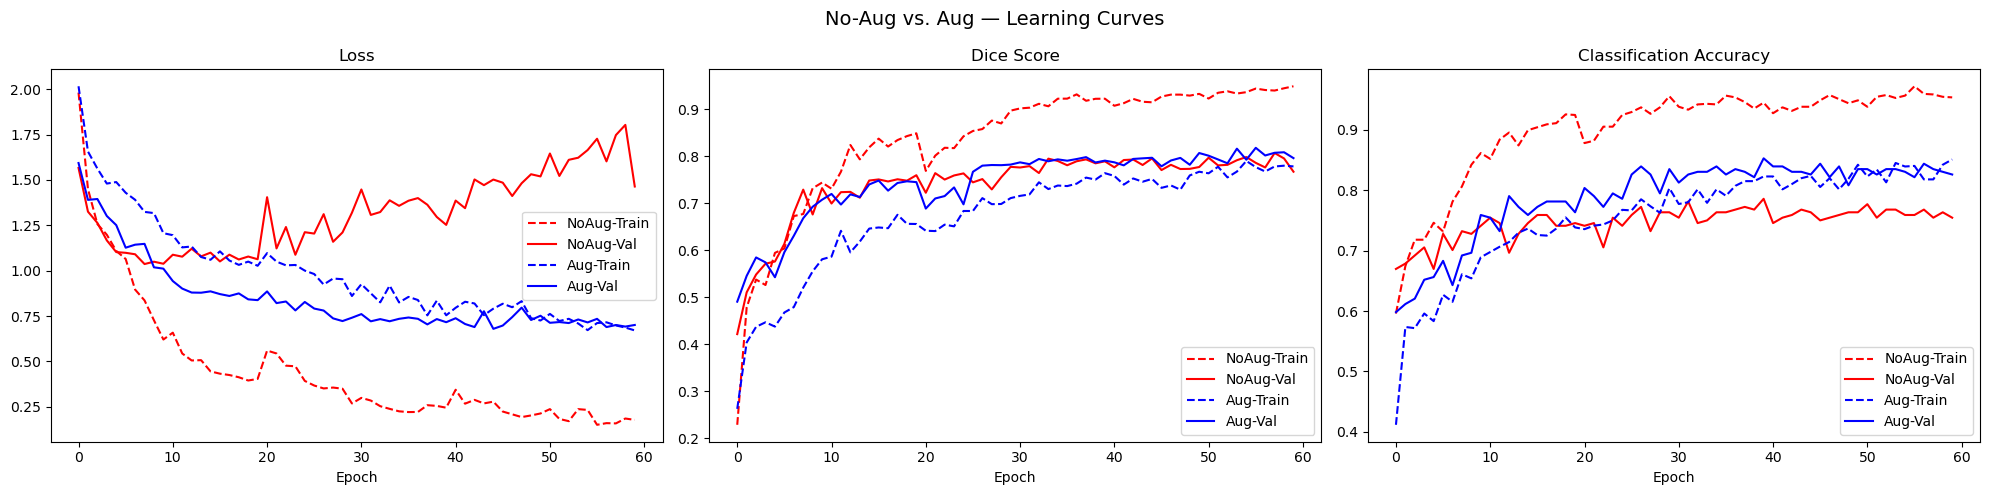

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("No-Aug vs. Aug — Learning Curves", fontsize=14)

keys = [("loss","Loss"),("dice","Dice Score"),("acc","Classification Accuracy")]
for ax, (key, title) in zip(axes, keys):
    ax.plot(history_noaug[f"train_{key}"], "--", color="red",  label="NoAug-Train")
    ax.plot(history_noaug[f"val_{key}"],   "-",  color="red",  label="NoAug-Val")
    ax.plot(history_aug[f"train_{key}"],   "--", color="blue", label="Aug-Train")
    ax.plot(history_aug[f"val_{key}"],     "-",  color="blue", label="Aug-Val")
    ax.set_title(title); ax.legend(); ax.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("aug_vs_noaug_comparison.png", dpi=150)
plt.show()


In [28]:
# ── Print Best Model Information ─────────────────────────────────────────────
import os
try:
    from torchinfo import summary as torch_summary
    USE_TORCHINFO = True
except ImportError:
    USE_TORCHINFO = False

# ── 1. Decide which checkpoint is "best" based on val_dice ───────────────────
best_val_dice_noaug = max(history_noaug["val_dice"]) if history_noaug["val_dice"] else -1
best_val_dice_aug   = max(history_aug["val_dice"])   if history_aug["val_dice"]   else -1

if best_val_dice_aug >= best_val_dice_noaug:
    best_tag      = "Aug"
    best_path     = "best_aug_model.pth"
    best_history  = history_aug
else:
    best_tag      = "NoAug"
    best_path     = "best_noaug_model.pth"
    best_history  = history_noaug

print("=" * 65)
print(f"  BEST MODEL SUMMARY  →  Experiment : {best_tag}")
print("=" * 65)

# ── 2. Config ────────────────────────────────────────────────────────────────
print("\n📋  Configuration")
print("-" * 40)
for k, v in CFG.items():
    print(f"  {k:<20} : {v}")

# ── 3. Architecture ──────────────────────────────────────────────────────────
print("\n🏗️   Architecture")
print("-" * 40)
print(f"  Backbone (encoder)   : {CFG['encoder_name']}")
print(f"  Segmentation head    : DeepLabV3+  (smp)")
print(f"  Input channels       : 1  (grayscale)")
print(f"  Seg output channels  : 1  (binary mask)")
print(f"  Cls output classes   : {CFG['num_classes']}  ({', '.join(LABEL2IDX.keys())})")
print(f"  Image size           : {CFG['img_size']} × {CFG['img_size']}")
print(f"  Classification head  : Linear(fused) → 512 → 256 → {CFG['num_classes']}")
print(f"  Multi-scale pooling  : enc[-1] + enc[-2]  (AdaptiveAvgPool2d)")

# ── 4. Parameter counts ──────────────────────────────────────────────────────
best_model = DualTaskModel(CFG["encoder_name"], CFG["num_classes"]).to(device)

if os.path.exists(best_path):
    best_model.load_state_dict(torch.load(best_path, map_location=device))
    print(f"\n✅  Loaded weights from  : {best_path}")
else:
    print(f"\n⚠️   Checkpoint not found : {best_path}  (showing architecture only)")

total_params     = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("\n🔢  Parameter counts")
print("-" * 40)
print(f"  Total params         : {total_params:,}")
print(f"  Trainable params     : {trainable_params:,}")
print(f"  Frozen params        : {frozen_params:,}")

# ── 5. Training metrics ──────────────────────────────────────────────────────
best_epoch_idx = int(best_history["val_dice"].index(max(best_history["val_dice"])))
print(f"\n📈  Best Training Snapshot  (epoch {best_epoch_idx + 1})")
print("-" * 40)
for metric in ["train_loss", "val_loss", "train_dice", "val_dice", "train_acc", "val_acc"]:
    print(f"  {metric:<18} : {best_history[metric][best_epoch_idx]:.4f}")



  BEST MODEL SUMMARY  →  Experiment : Aug

📋  Configuration
----------------------------------------
  data_root            : C:\\Users\\ASHAH\\Desktop\\DL_Project\\breast_ultrasound\\combined_breast_ultrasound_dataset
  img_size             : 320
  batch_size           : 8
  epochs               : 60
  lr                   : 0.0003
  num_workers          : 0
  encoder_name         : timm-efficientnet-b3
  threshold            : 0.5
  num_classes          : 3
  cls_weight           : 0.8
  unfreeze_epoch       : 5
  patience             : 12
  norm_mean            : 0.485
  norm_std             : 0.229

🏗️   Architecture
----------------------------------------
  Backbone (encoder)   : timm-efficientnet-b3
  Segmentation head    : DeepLabV3+  (smp)
  Input channels       : 1  (grayscale)
  Seg output channels  : 1  (binary mask)
  Cls output classes   : 3  (benign, malignant, normal)
  Image size           : 320 × 320
  Classification head  : Linear(fused) → 512 → 256 → 3
  Multi-scale